## Assignment 01 - EN3160
### Fernando H.M.D. - 230180F

Question 01

In [161]:
# Intensity transformation functions
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q1.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [162]:
def intensity_transform(im, breakpoints):

    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    im_float = im.astype(np.float32)
    transformed = np.zeros_like(im_float)

    # Piecewise linear interpolation
    lut = np.zeros(256, dtype=np.float32)

    intensity_values = np.arange(256, dtype=np.float32)

    # Process each pair of consecutive breakpoints
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x1 == x2:
            continue

        # Intensities lying on this segment
        mask = (
            (intensity_values >= x1) &
            (intensity_values <= x2)
        )

        lut[mask] = (
            y1
            + (y2 - y1) *
            (intensity_values[mask] - x1) /
            (x2 - x1)
        )
        
    # At repeated x-values, use the value AFTER the jump
    for i in range(len(breakpoints) - 1):
        if x[i] == x[i + 1]:
            jump_x = int(x[i])
            lut[jump_x] = y[i + 1]

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[im]


In [163]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [200, 200],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)


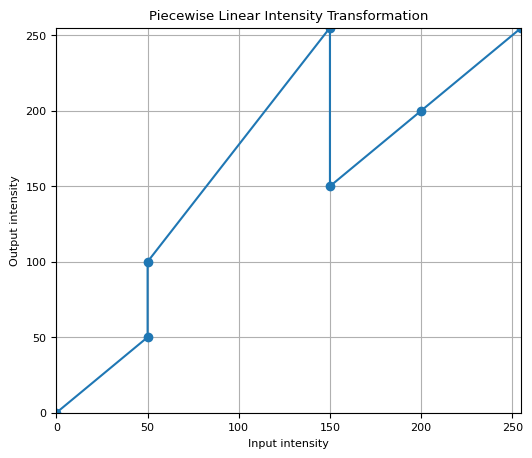

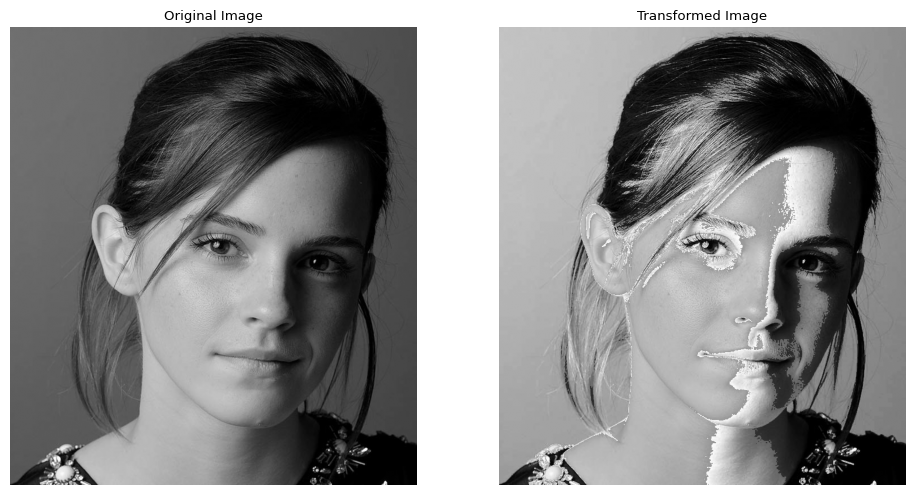

In [164]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

For a visually pleasing output

In [165]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 100],
    [150, 150],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)

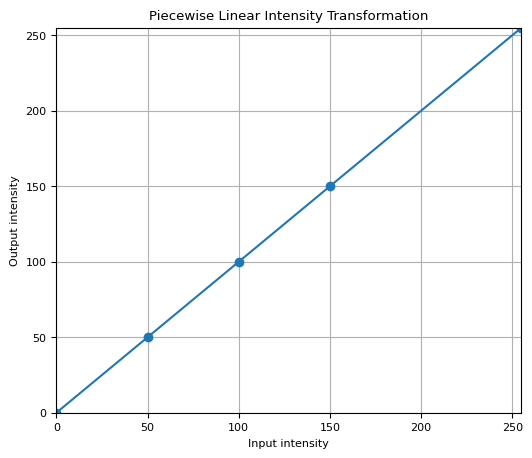

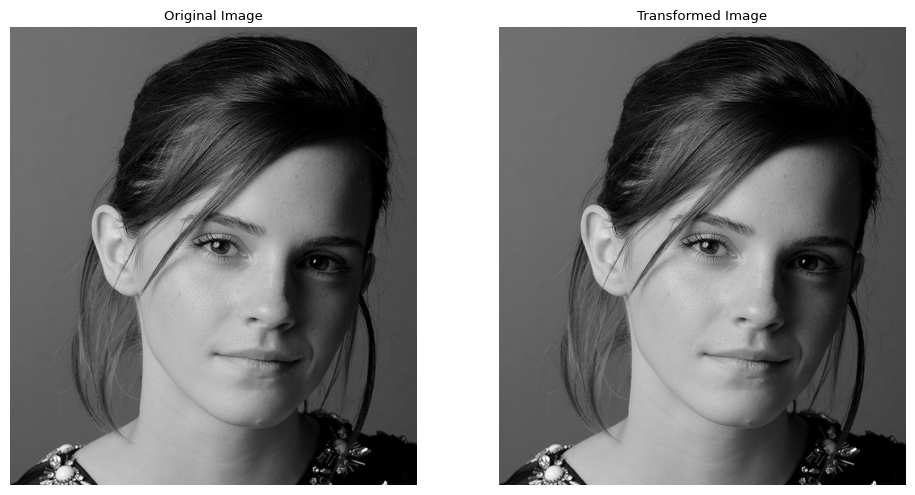

In [166]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Question 2

In [167]:
img = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q2.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

print("image shape", img.shape)

image shape (217, 181)


White matter and Gray matter in a brain proton density image does not mean the places with high pixel intensities and lower areas. rather, White and Gray matter means seperate areas of tissue.

To find the pixel intensities of the designated areas, we can inspect biological areas of white and gray matter. We can inspect that the gray matter is in the region of Y[80:90], X[30:40]... the wrinkly outer tissue of the brain. And the white matter is roughly Y[100:120] X[50:70] region. The white range in the middle is not white matter. that is CSF region.

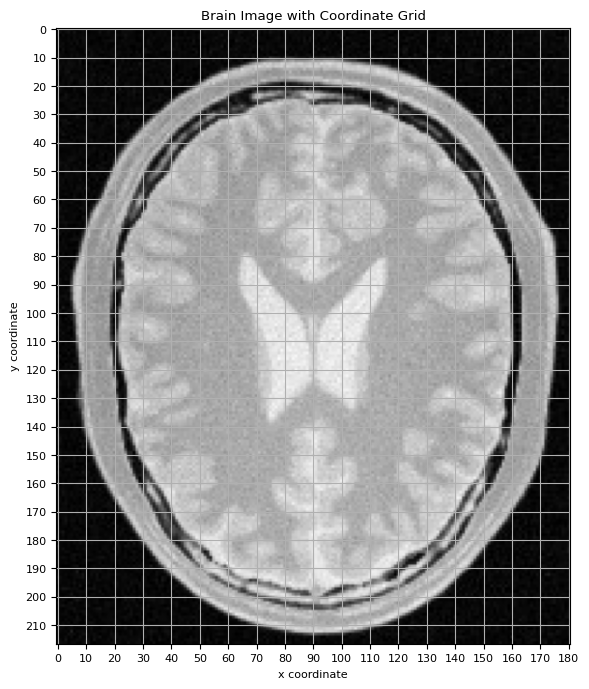

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(img, cmap="gray", vmin=0, vmax=255)

plt.xticks(range(0, img.shape[1], 10))
plt.yticks(range(0, img.shape[0], 10))

plt.grid(True)

plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.title("Brain Image with Coordinate Grid")

plt.show()

In [169]:
white_roi = img[100:120, 50:60]

print("White matter mean:", np.mean(white_roi))
print("White matter min :", np.min(white_roi))
print("White matter max :", np.max(white_roi))

gray_roi = img[150:160, 40:50]

print("Gray matter mean:", np.mean(gray_roi))
print("Gray matter min :", np.min(gray_roi))
print("Gray matter max :", np.max(gray_roi))

White matter mean: 167.21
White matter min : 148
White matter max : 194
Gray matter mean: 196.85
Gray matter min : 171
Gray matter max : 222


Now, I am using Gaussian pulse as the intensity transformation function to accentuate only the required range of pixel intensities. The reason to use Gaussian pulse rather than block pixels is to remove the jump discontinuities and obtain a smooth contrast from the rest of the image. The white matter is centered arounf 167.21 ~ 165 and gray matter is centered arounf 196.85 ~ 200. Such is the value of miu. As for sigma, sigma reflects the range of values that will be accentuated.

In [170]:
def gaussian_intensity_transform(im, mu, sigma):
    x = np.arange(256)

    # Create transformation
    T = 255 * np.exp(
        -((x - mu) ** 2) / (2 * sigma ** 2)
    )

    T = np.clip(T, 0, 255).astype(np.uint8)

    # Apply lookup table to image
    transformed = T[im]

    return transformed, T

In [171]:
white_matter, T_white = gaussian_intensity_transform(
    img, mu=165, sigma=15
)

gray_matter, T_gray = gaussian_intensity_transform(
    img, mu=200, sigma=15
)

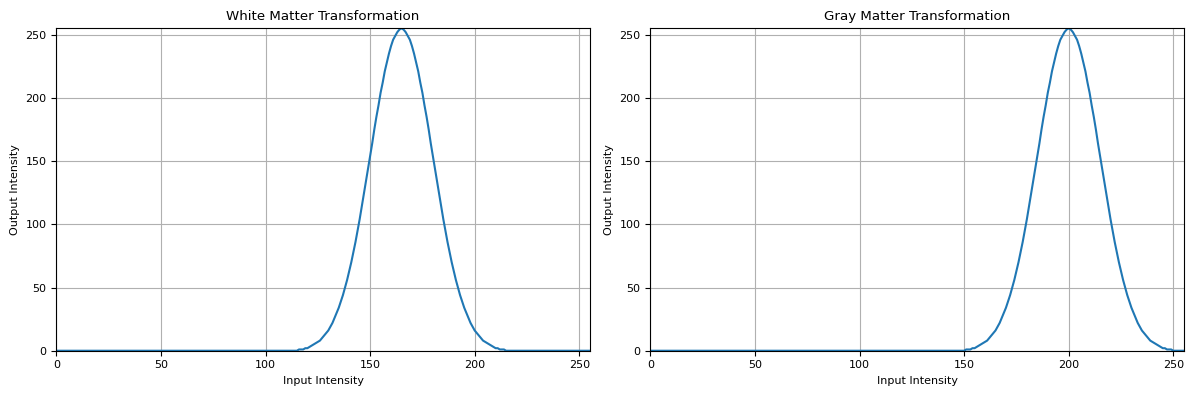

In [172]:
x = np.arange(256)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, T_white)
axes[0].set_title("White Matter Transformation")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid()

axes[1].plot(x, T_gray)
axes[1].set_title("Gray Matter Transformation")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid()

plt.tight_layout()
plt.show()

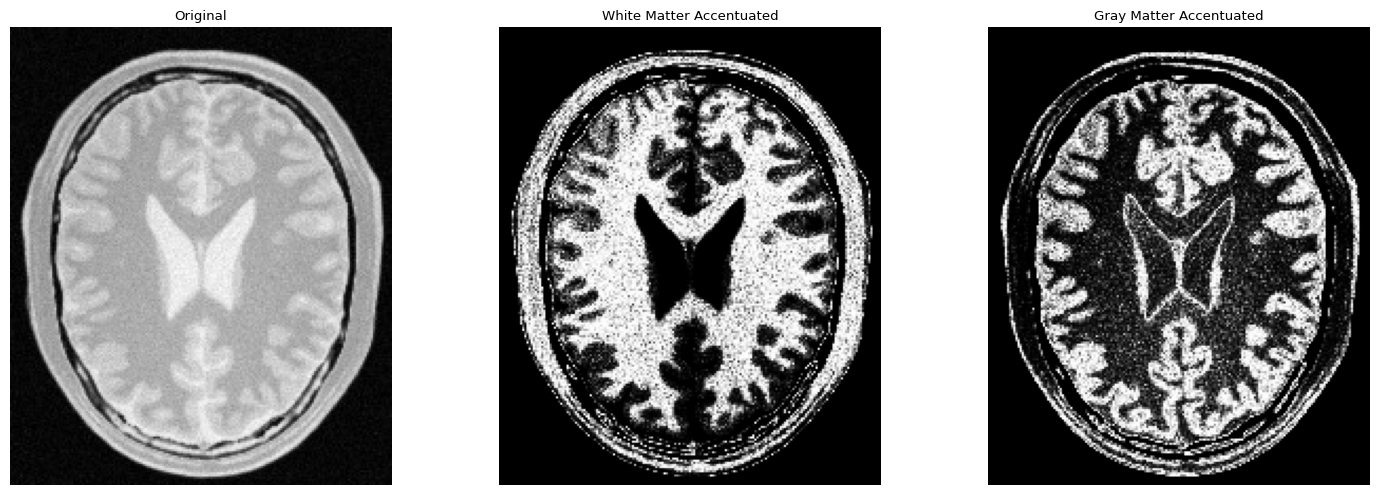

In [173]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(white_matter, cmap="gray")
axes[1].set_title("White Matter Accentuated")

axes[2].imshow(gray_matter, cmap="gray")
axes[2].set_title("Gray Matter Accentuated")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Question 03

In this question, we talk about L* a* b* colour images. 
In an RGB image, the brightness of the image is not an attribute that i controlled by just R, g or B, but by the combination of all three. So, doing a gamma correction on an RGB image can alter the colours of the image. A way to prevent this is to, apply gamma correction in the Lab plane. In Lab plane, the image is segragrated to 
$$L∗ =lightness $$
$$ a^* = \text{green} \leftrightarrow \text{red} $$
$$ b∗=blue↔yellow $$
Then we apply gamma to the L* plane.

In [174]:
img3 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q3.jpeg")

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [175]:
img3_lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
L, a, b = cv2.split(img3_lab)

In [176]:
# Applying gamma correction to the L place. 
gamma = 0.8
lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

L_modified = cv2.LUT(L, lut)

# Merge back and convert to BGR
corrected_lab = cv2.merge([L_modified, a, b])
corrected_bgr = cv2.cvtColor(corrected_lab, cv2.COLOR_LAB2BGR)
corrected_rgb = cv2.cvtColor(corrected_lab, cv2.COLOR_LAB2RGB)

(np.float64(-0.5), np.float64(719.5), np.float64(479.5), np.float64(-0.5))

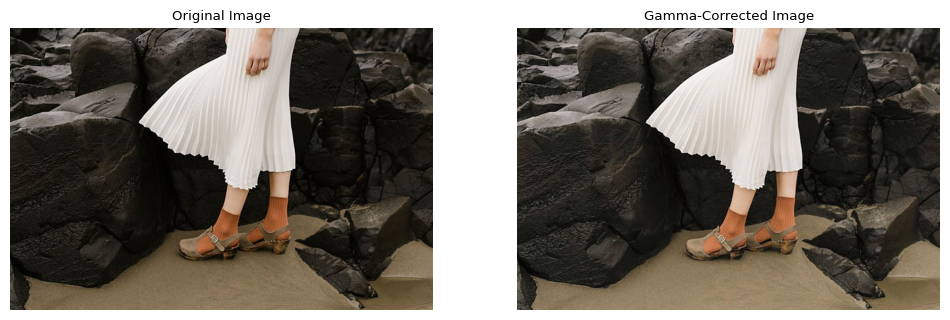

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
colors = ('r', 'g', 'b')

# --- Row 1: Images ---
axes[0].imshow(img3_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(corrected_rgb)
axes[1].set_title("Gamma-Corrected Image")
axes[1].axis("off")

The gamma correction has made the darker areas specially the rock, more detailed and less shadowy. 

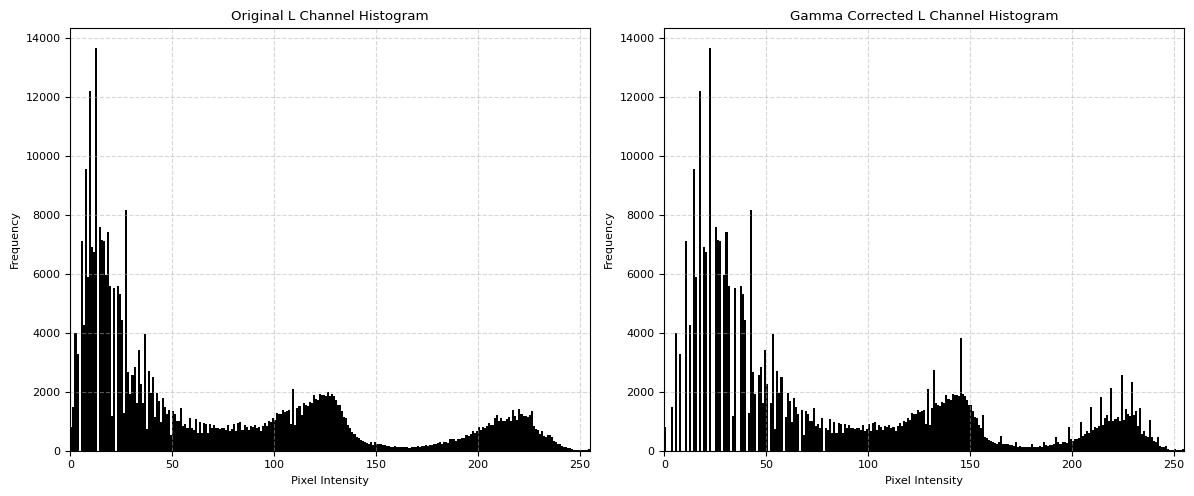

In [178]:
#Histograms of L
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(L.ravel(), bins=256, range=[0, 256], color='black')
axes[0].set_title("Original L Channel Histogram")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 255)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gamma Corrected L Histogram
axes[1].hist(L_modified.ravel(), bins=256, range=[0, 256], color='black')
axes[1].set_title("Gamma Corrected L Channel Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

We can clearly see the effect of the gamma correction in the second histogram, where the low intensity pixels are mapped into a ligheter range. That is, the darker areas are lightened. 

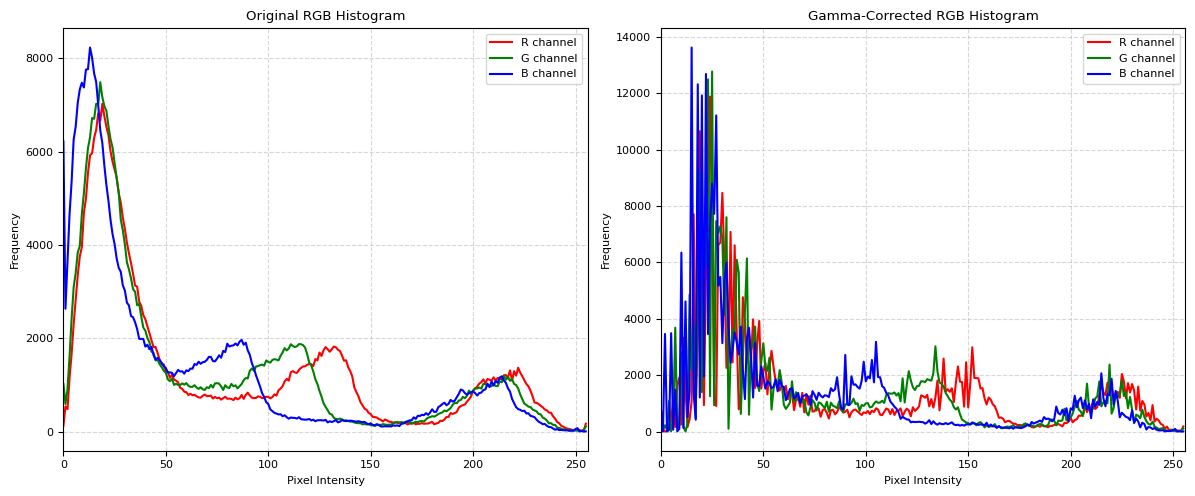

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original Image RGB Histogram

for i, col in enumerate(colors):
    hist = cv2.calcHist([img3_rgb], [i], None, [256], [0, 256])
    axes[0].plot(hist, color=col, label=f"{col.upper()} channel")

axes[0].set_title("Original RGB Histogram")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim([0, 256])
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Corrected Image RGB Histogram
for i, col in enumerate(colors):
    hist = cv2.calcHist([corrected_rgb], [i], None, [256], [0, 256])
    axes[1].plot(hist, color=col, label=f"{col.upper()} channel")

axes[1].set_title("Gamma-Corrected RGB Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Interpretation of results:
Gamma correction is a nonlinear transformation. It is going to transform the L and the RGB planes non linearly. This accounts for the noisy like histograms.

Question 04

In this question, we split the image into, Hue, Saturation and Value/ Brightness planes. Instead of directly chandinng the value of brightness, we apply a gaussian smoothing function centered around 128, with a variance of 70 to the Saturation plane. 

Saturation has higher values for high colour areas ex: the spider man suit, zendaya hair where as lower values for less colourfull areas ex: buildings. Thus, applying the transformatio to the saturation plane,enhances the visibility of colours that is, makes the image look more colourful/vivid.

In [180]:
img4 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q4.jpeg", cv2.IMREAD_COLOR_RGB)

if img4 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [181]:
# Splitting into Saturation, Hue and Value planes
img4_HSV = cv2.cvtColor(img4, cv2.COLOR_RGB2HSV)

H, S, V = cv2.split(img4_HSV)

The value of \(a\) determines the strength of the vibrance enhancement applied to the saturation plane. When \(a=0\), the transformation reduces to the identity transformation. As \(a\) increases, the saturation of the image increases, making the existing colours appear more vivid while preserving their hue.

In [182]:
def intensity_transform(x, a, sigma):
    x = np.array(x, dtype=np.float64)
    
    gaussian_term = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma ** 2)))
    transformed = x + gaussian_term
    
    result = np.minimum(transformed, 255.0)
    
    return np.round(result).astype(np.uint8)

# Apply the transformation to the Saturation channel
saturated_image = intensity_transform(S, a=0.65, sigma=70)

corrected_hsv = cv2.merge([H, saturated_image, V])
corrected_rgb = cv2.cvtColor(corrected_hsv, cv2.COLOR_HSV2RGB)

After careful tryouts $$a=0.65$$ was selected as the best vlue for the image to look visually pleasing without having extreme colour contrasts.

In the image, it can be seen that the red colour of the suit and orange of hair are more highlighted than the original image. This is the difference done by the transformation.

(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

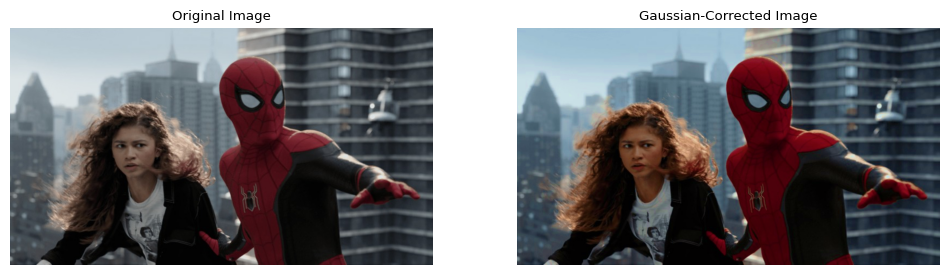

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# --- Row 1: Images ---
axes[0].imshow(img4)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(corrected_rgb)
axes[1].set_title("Gaussian-Corrected Image")
axes[1].axis("off")

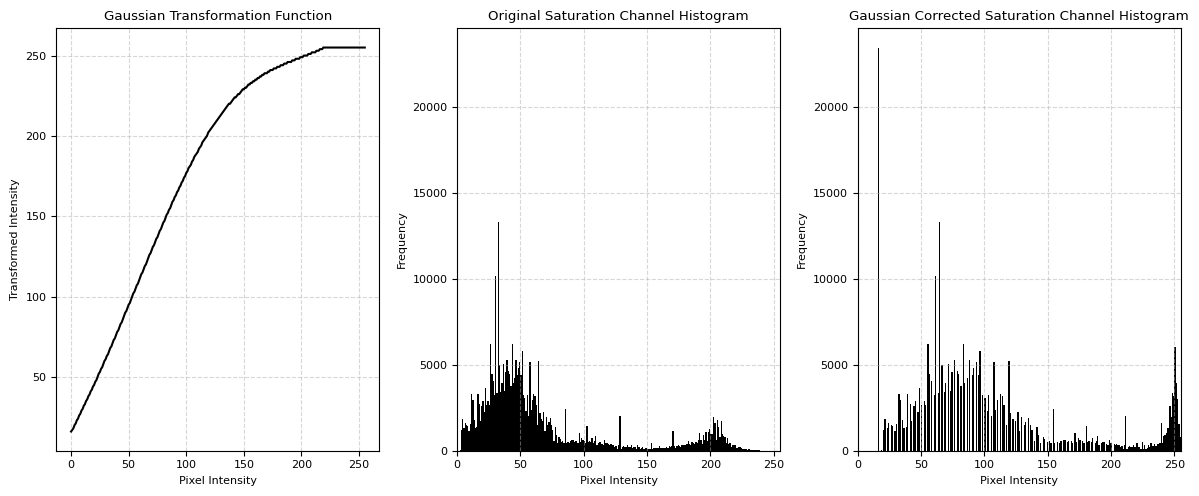

In [184]:
#Histograms of Saturation
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# gaussian transformation plot
axes[0].plot(np.arange(256), intensity_transform(np.arange(256), a=0.65, sigma=70), color='black')
axes[0].set_title("Gaussian Transformation Function")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Transformed Intensity")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(S.ravel(), bins=256, range=[0, 256], color='black')
axes[1].set_title("Original Saturation Channel Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Gaussian Corrected Saturation Histogram
axes[2].hist(saturated_image.ravel(), bins=256, range=[0, 256], color='black')
axes[2].set_title("Gaussian Corrected Saturation Channel Histogram")
axes[2].set_xlabel("Pixel Intensity")
axes[2].set_ylabel("Frequency")
axes[2].set_xlim(0, 255)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Question 05

In [191]:
img5 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q5.tif", cv2.IMREAD_GRAYSCALE)

if img5 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

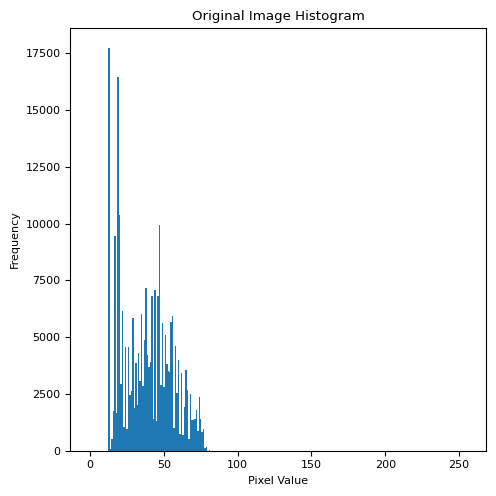

In [203]:
# get the histogram of the original image
hist, bins = np.histogram(img5.flatten(), 256, [0, 256])

fig, axes = plt.subplots(1, 1, figsize=(5, 5))
plt.bar(x, hist, width=1)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Original Image Histogram')
plt.tight_layout()
plt.show()

We can see that the image has more pixels in the range of low pixel values.
Now let us apply histogram equalization.
\begin{equation}
s_k = T(r_k) = \frac{L-1}{MN} \sum_{j=0}^{k} n_j
\end{equation}

In [211]:
# Histogram Equalization using the equation

# Compute the cumulative distribution function (CDF)
def histogram_equalization(img):

    hist = np.zeros(256, dtype=np.int64)

    for pixel in img.ravel():
        hist[pixel] += 1

    cdf = np.zeros(256, dtype=np.float64)

    for i in range(256):
        cdf[i] = np.sum(hist[:i + 1])
        cdf[i] = cdf[i] / img.size

    mapping = np.round(255 * cdf).astype(np.uint8)

    equalized = mapping[img]

    return equalized
img5_eq = histogram_equalization(img5)

hist_equalized = np.zeros(256, dtype=np.int64)

for pixel in img5_eq.ravel():
    hist_equalized[pixel] += 1

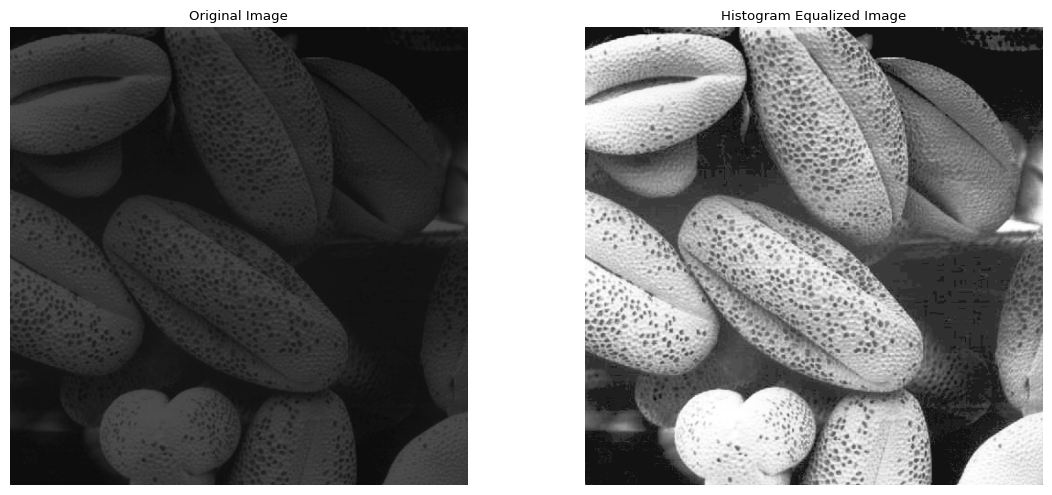

In [212]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img5, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(img5_eq, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Histogram Equalized Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

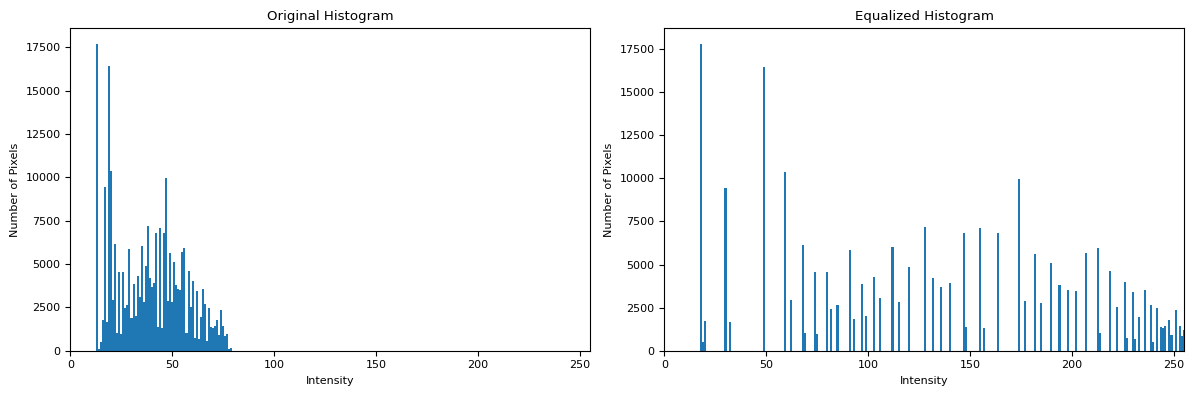

In [213]:
x = np.arange(256)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, hist, width=1)
axes[0].set_title("Original Histogram")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Number of Pixels")
axes[0].set_xlim(0, 255)

axes[1].bar(x, hist_equalized, width=1)
axes[1].set_title("Equalized Histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Number of Pixels")
axes[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

Histogram equalization spreads out the pixel values more evenly, especially when they were previously packed into a smaller range of intensities. 

However, this does not mean that every histogram bin will be filled or that every bin will have the same frequency. It only gives a rough equalization of the intensity distribution.

Question 06

Histogram Equalization of foreground

In [214]:
img6 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q6.jpeg", cv2.IMREAD_COLOR_RGB)

if img6 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

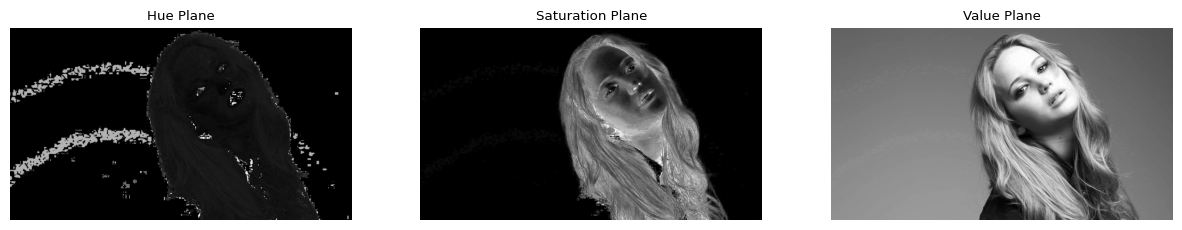

In [275]:
img6_HSV = cv2.cvtColor(img6, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(img6_HSV)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(H, cmap='gray')
axes[0].set_title('Hue Plane')

axes[1].imshow(S, cmap='gray')
axes[1].set_title('Saturation Plane')

axes[2].imshow(V, cmap='gray')
axes[2].set_title('Value Plane')

for ax in axes:
    ax.axis('off')

plt.show()

From this image, we can deduce that the saturation plane focuses more on the foreground image. 
So, for the question, to apply histogram equalization to the foreground, we pick the saturation plane.

Now, lets mask it and threshold. 


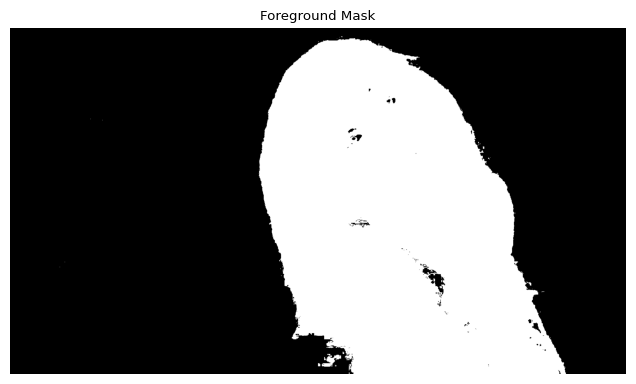

In [ ]:
# Example: using the Saturation plane
_, mask = cv2.threshold(S, 13, 255, cv2.THRESH_BINARY)
hist, bins = np.histogram(mask.flatten(), 256, [0, 256])

plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

After experimenting on the value of the threold of the mask, i deduced on 13 as the lower threshold and 255 as the upper threshold to capture all of the foreground of the image. 

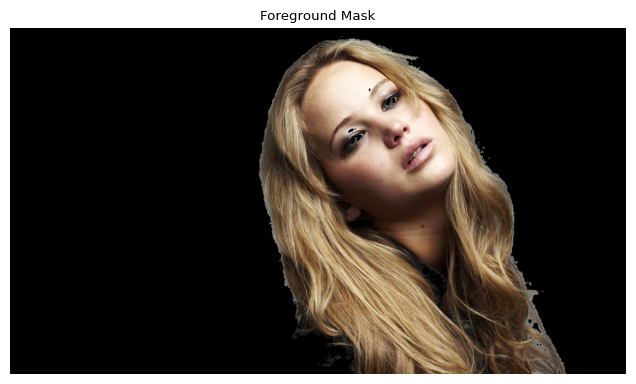

In [284]:
# Obtaining the foreground mask using cv.bitwise operations

foreground = cv2.bitwise_and(img6, img6, mask=mask)
hist, bins = np.histogram(foreground.flatten(), 256, [0, 256])

plt.imshow(foreground)
plt.title("Foreground Mask")
plt.axis("off")

plt.tight_layout()  
plt.show()

This shows the foreground extracted image - when using the cv.bitwise_and, the background values all becomes $0$. Only the foreground values stay preserved.

Now, we can compare the histograms of value/brightness before and after the cv.bitwise_and.

We compare the value and equalize that, so that the colours do not get distort.

Equalized Values: [ 94  94  99 ... 104 118 114]
foreground_values: [ 99  99 104 ... 108 119 116]


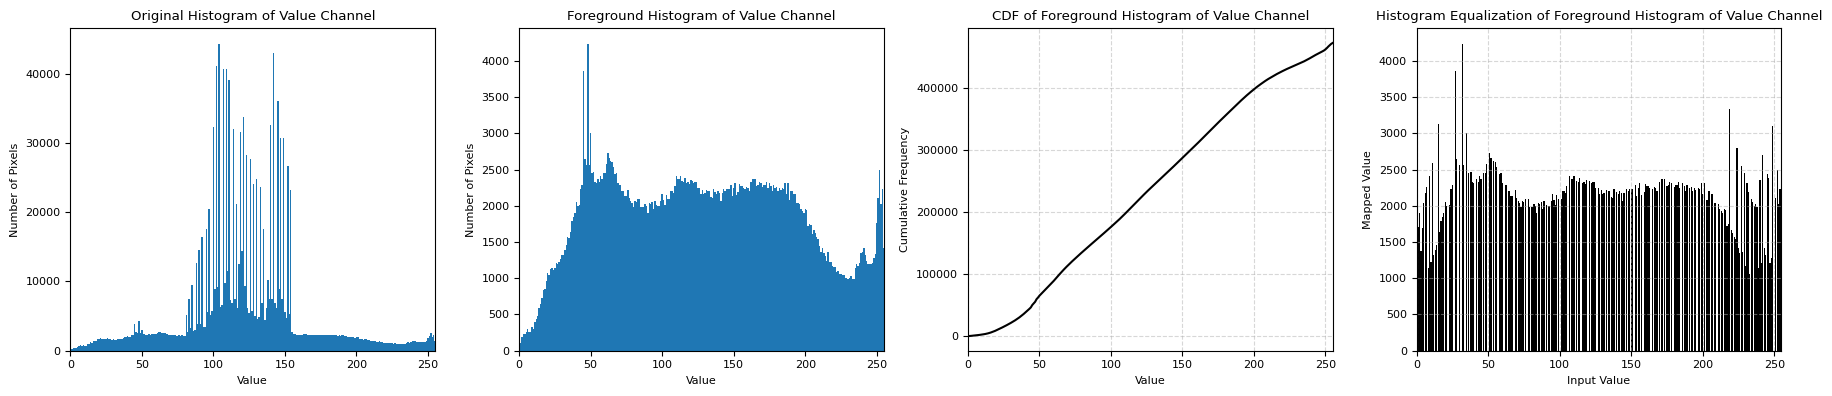

In [ ]:
#Histogram of value in original image
hist, bins = np.histogram(V.flatten(), 256, [0, 256])

H_f, S_f, V_f = cv2.split(cv2.cvtColor(foreground, cv2.COLOR_RGB2HSV))

foreground_values = V_f[mask == 255]

hist_f, bins_f = np.histogram(foreground_values, bins=256, range=(0, 256))

cdf_f = np.cumsum(hist_f)

# Equalization of the foreground histogram of the Value channel
total_fg_pixels = cdf_f[-1]  
lut = np.round((255.0 / total_fg_pixels) * cdf_f).astype(np.uint8)
V_eq = np.zeros_like(V_f, dtype=np.uint8)
V_eq[mask > 0] = lut[V_f[mask > 0]] # only the nonzero values are equalized
equalized_values = V_eq[mask > 0]
hist_eq, _ = np.histogram(equalized_values, bins=256, range=(0, 256))


fig, axes = plt.subplots(1, 4, figsize=(18, 4))

x = np.arange(256)

axes[0].bar(x, hist, width=1)
axes[0].set_title("Original Histogram of Value Channel")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Number of Pixels")
axes[0].set_xlim(0, 255)

axes[1].bar(x, hist_f, width=1)
axes[1].set_title("Foreground Histogram of Value Channel")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Number of Pixels")
axes[1].set_xlim(0, 255)

axes[2].plot(cdf_f, color='black')
axes[2].set_title("CDF of Foreground Histogram of Value Channel")
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Cumulative Frequency")
axes[2].set_xlim(0, 255)
axes[2].grid(True, linestyle='--', alpha=0.5)   

axes[3].bar(range(256), hist_eq, color='black')
axes[3].set_title("Histogram Equalization of Foreground Histogram of Value Channel")
axes[3].set_xlabel("Input Value")
axes[3].set_ylabel("Mapped Value")
axes[3].set_xlim(0, 255)
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

To get the foreground histogram, only the filtered non zero values are considered. Otherwise, there will be a too big of a spike at zero and the rest would not be intelligible. 

Now, lets apply histogram equalization.

Now we can see the histogram equalized V channe of the image. Only the foreground pixels are equalized. The background pixels are all 0. They are filtered out.

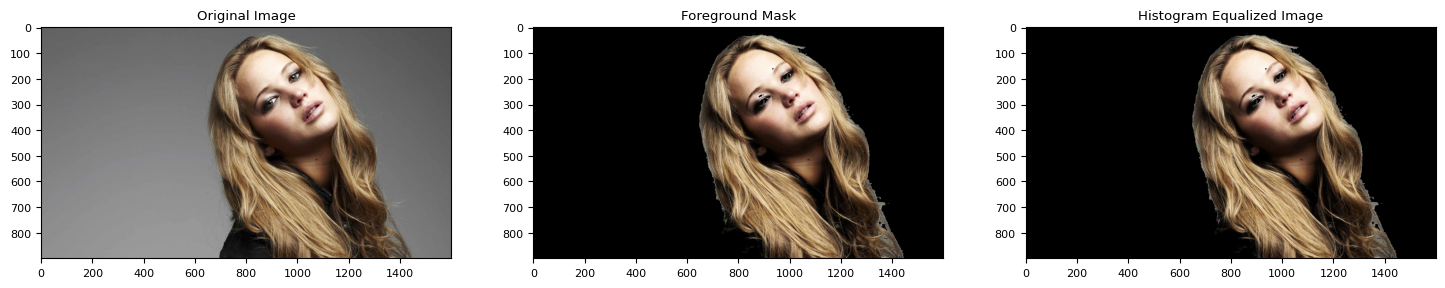

In [343]:
# histogram equalized image
Equalized_HSV = cv2.merge([H, S, V_eq])
Equalized_RGB = cv2.cvtColor(Equalized_HSV, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img6)
axes[0].set_title("Original Image")

axes[1].imshow(foreground)
axes[1].set_title("Foreground Mask")

axes[2].imshow(Equalized_RGB)
axes[2].set_title("Histogram Equalized Image")
plt.show()

The image shows the original image of jennifer and her foreground image and the histogram equalized foreground image. 

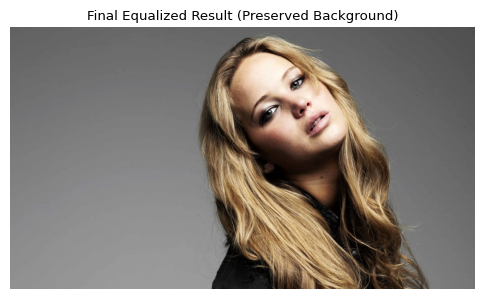

In [344]:
background = cv2.bitwise_and(img6, img6, mask=cv2.bitwise_not(mask))

foreground_equalized = Equalized_RGB 

final_image = cv2.add(foreground_equalized, background)

plt.figure(figsize=(6, 6))
plt.imshow(final_image)
plt.title("Final Equalized Result (Preserved Background)")
plt.axis("off")
plt.show()

This is the final equalised foreground with background.

Question 07

In this question we are going to test sobel filtering. 

Sobel filter is mainly used to identify edges. The sobel filter kernal is $$[[1, 0, -1], [2, 0, -2], [1, 0, -1]]$$ this is the verticle sobel filter, and can be used to identify horizontal edges.

In [345]:
img7 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q7.jpeg", cv2.IMREAD_GRAYSCALE)

if img7 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

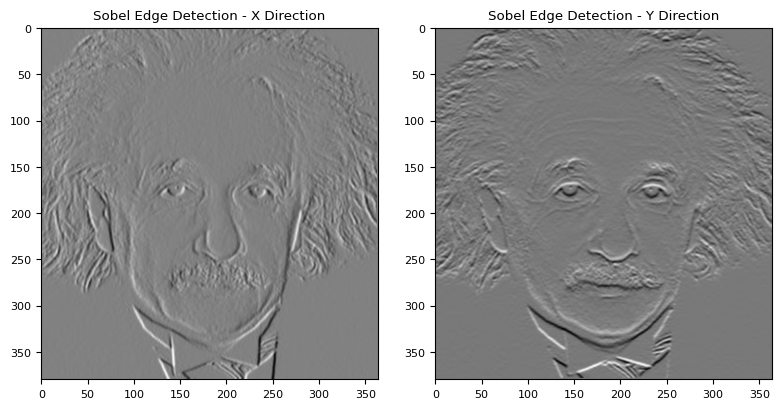

In [365]:
# Existing 2D sobel edge detection

kernalx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
kernaly = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

sobel_x = cv2.filter2D(img7, ddepth=cv2.CV_64F, kernel=kernalx)
sobel_y = cv2.filter2D(img7, ddepth=cv2.CV_64F, kernel=kernaly)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sobel_x, cmap='gray')
axes[0].set_title('Sobel Edge Detection - X Direction')
axes[1].imshow(sobel_y, cmap='gray')
axes[1].set_title('Sobel Edge Detection - Y Direction')

plt.tight_layout()
plt.show()

# taking abs instead of clipping at zero can detect more edges, becuase clipping at zero disregards all negative gradients and abs at least potraits them without hiding them.
# or, we can directly use imshow, which would map the minimum and maximum values to 0 to 255 making it possible to show more edges, 
# but it would not be a good representation of the actual gradient values.

In [366]:
# own code to sobel edge detection
def manual_filter2D(img, kernel):

    h, w = img.shape
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    # Pad image so output has same size
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    # Use float so negative gradients are preserved
    output = np.zeros((h, w), dtype=np.float64)

    for y in range(h):
        for x in range(w):
            region = padded[y:y + kh, x:x + kw]
            output[y, x] = np.sum(region * kernel)

    return output

sobel_x_manual = manual_filter2D(img7, kernalx)
sobel_y_manual = manual_filter2D(img7, kernaly)

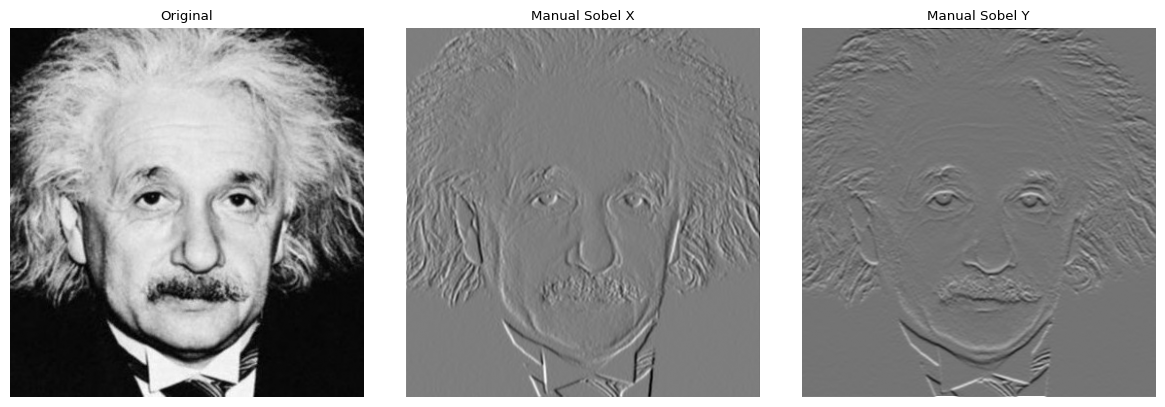

In [367]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img7, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(sobel_x_manual, cmap='gray')
axes[1].set_title('Manual Sobel X')

axes[2].imshow(sobel_y_manual, cmap='gray')
axes[2].set_title('Manual Sobel Y')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

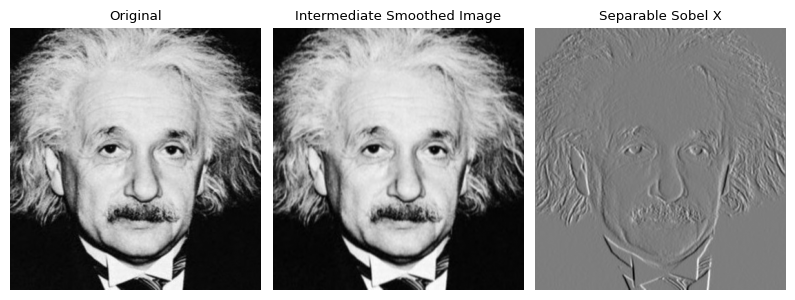

In [368]:
# 1D Sobel components
smooth_col = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

derivative_row = np.array([
    [1, 0, -1]
], dtype=np.float32)

# First smooth vertically
temp_x = cv2.filter2D(img7, cv2.CV_64F, smooth_col)

# Then take horizontal derivative
sobel_x_separable = cv2.filter2D(temp_x, cv2.CV_64F, derivative_row)

fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(img7, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(temp_x, cmap='gray')
axes[1].set_title('Intermediate Smoothed Image')

axes[2].imshow(sobel_x_separable, cmap='gray')
axes[2].set_title('Separable Sobel X')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

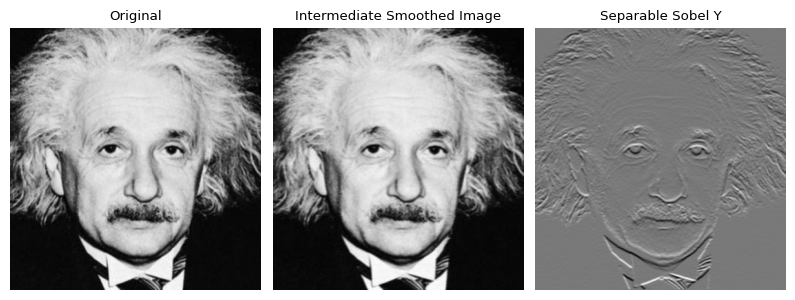

In [369]:
smooth_row = np.array([
    [1, 2, 1]
], dtype=np.float32)

derivative_col = np.array([
    [1],
    [0],
    [-1]
], dtype=np.float32)

# First smooth horizontally
temp_y = cv2.filter2D(img7, cv2.CV_64F, smooth_row)

# Then take vertical derivative
sobel_y_separable = cv2.filter2D(temp_y, cv2.CV_64F, derivative_col)

fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(img7, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(temp_y, cmap='gray')
axes[1].set_title('Intermediate Smoothed Image')

axes[2].imshow(sobel_y_separable, cmap='gray')
axes[2].set_title('Separable Sobel Y')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Question 08

Function to execute zooming using nearest neighbour and bilinear transformation

In [370]:
def zoom(img, factor, interpolation): #using nearest or bilinear interpolation
    if interpolation == 'nearest':
        zoomed = cv2.resize(img, None, fx=factor, fy=factor, interpolation=cv2.INTER_NEAREST)
    elif interpolation == 'bilinear':
        zoomed = cv2.resize(img, None, fx=factor, fy=factor, interpolation=cv2.INTER_LINEAR)
    else:
        raise ValueError("Interpolation method must be 'nearest' or 'bilinear'.")
    return zoomed

In [385]:
def Mean_Squared_Error(img1, img2):

    # Find common height and width
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])

    # Crop both images to the same size
    img1_crop = img1[:h, :w]
    img2_crop = img2[:h, :w]

    # Compute MSE
    mse = np.mean(
        (img1_crop.astype(np.float64) -
         img2_crop.astype(np.float64)) ** 2
    )

    return mse

In [372]:
# Image 01
img01small = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im01small.png", cv2.IMREAD_COLOR_RGB)

if img01small is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

img01 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im01.png", cv2.IMREAD_COLOR_RGB)

if img01 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [373]:
# Image 02
img02small = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im02small.png", cv2.IMREAD_COLOR_RGB)

if img02small is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

img02 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im02.png", cv2.IMREAD_COLOR_RGB)

if img02 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [374]:
# Image 03
img03small = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im03small.png", cv2.IMREAD_COLOR_RGB)

if img03small is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

img03 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im03.png", cv2.IMREAD_COLOR_RGB)

if img03 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [376]:
# Image 04
img04small = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im04small.jpg", cv2.IMREAD_COLOR_RGB)

if img04small is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

img04 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\im04.jpg", cv2.IMREAD_COLOR_RGB)

if img04 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

Text(0.5, 1.0, 'Bilinear Interpolation\nMSE: 115.09')

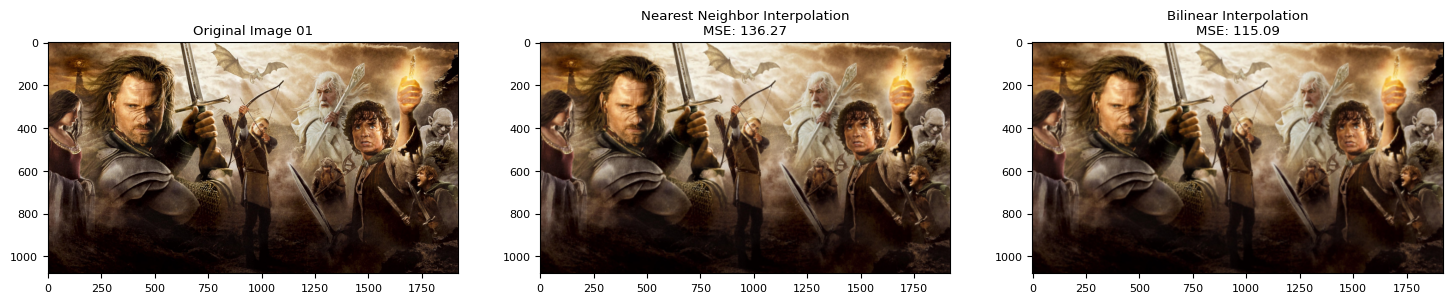

In [381]:
# Image 01
image01_nearest = zoom(img01small, 4, 'nearest')
image01_bilinear = zoom(img01small, 4, 'bilinear')
image01_mse_nearest = Mean_Squared_Error(image01_nearest, img01)
image01_mse_bilinear = Mean_Squared_Error(image01_bilinear, img01)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img01, cmap='gray')
axes[0].set_title('Original Image 01')

axes[1].imshow(image01_nearest, cmap='gray')
axes[1].set_title(f'Nearest Neighbor Interpolation\nMSE: {image01_mse_nearest:.2f}')

axes[2].imshow(image01_bilinear, cmap='gray')
axes[2].set_title(f'Bilinear Interpolation\nMSE: {image01_mse_bilinear:.2f}')

Text(0.5, 1.0, 'Bilinear Interpolation\nMSE: 18.35')

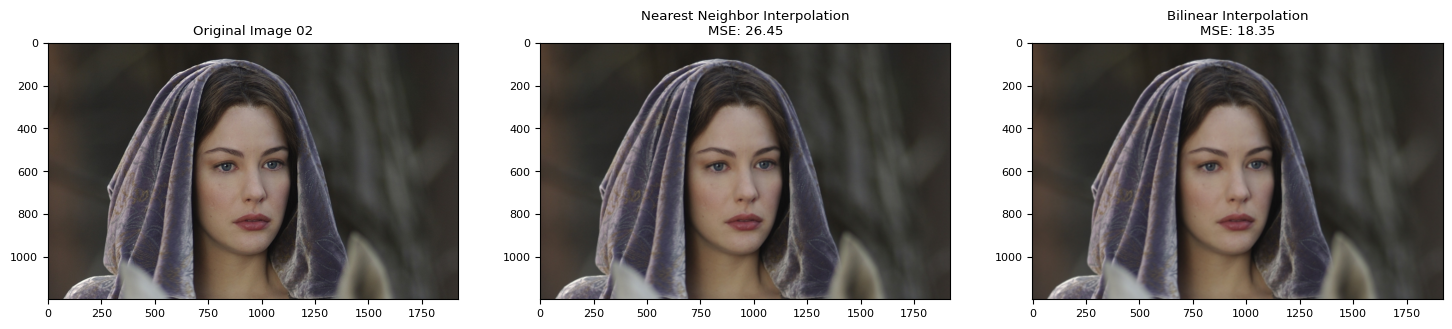

In [387]:
# Image 02
image02_nearest = zoom(img02small, 4, 'nearest')
image02_bilinear = zoom(img02small, 4, 'bilinear')
image02_mse_nearest = Mean_Squared_Error(image02_nearest, img02)
image02_mse_bilinear = Mean_Squared_Error(image02_bilinear, img02)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img02, cmap='gray')
axes[0].set_title('Original Image 02')

axes[1].imshow(image02_nearest, cmap='gray')
axes[1].set_title(f'Nearest Neighbor Interpolation\nMSE: {image02_mse_nearest:.2f}')

axes[2].imshow(image02_bilinear, cmap='gray')
axes[2].set_title(f'Bilinear Interpolation\nMSE: {image02_mse_bilinear:.2f}')

Text(0.5, 1.0, 'Bilinear Interpolation\nMSE: 51.20')

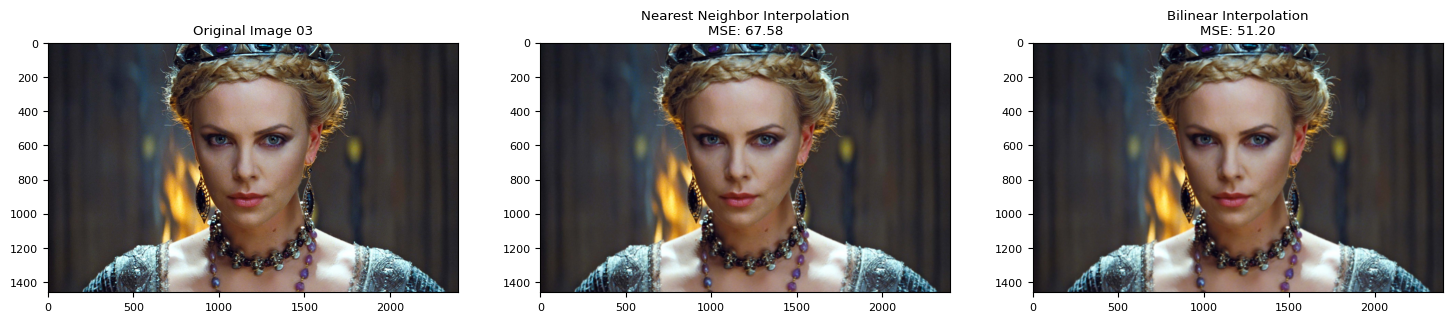

In [386]:
# Image 03
image03_nearest = zoom(img03small, 4, 'nearest')
image03_bilinear = zoom(img03small, 4, 'bilinear')
image03_mse_nearest = Mean_Squared_Error(image03_nearest, img03)
image03_mse_bilinear = Mean_Squared_Error(image03_bilinear, img03)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img03, cmap='gray')
axes[0].set_title('Original Image 03')

axes[1].imshow(image03_nearest, cmap='gray')
axes[1].set_title(f'Nearest Neighbor Interpolation\nMSE: {image03_mse_nearest:.2f}')

axes[2].imshow(image03_bilinear, cmap='gray')
axes[2].set_title(f'Bilinear Interpolation\nMSE: {image03_mse_bilinear:.2f}')

Text(0.5, 1.0, 'Bilinear Interpolation\nMSE: 197.41')

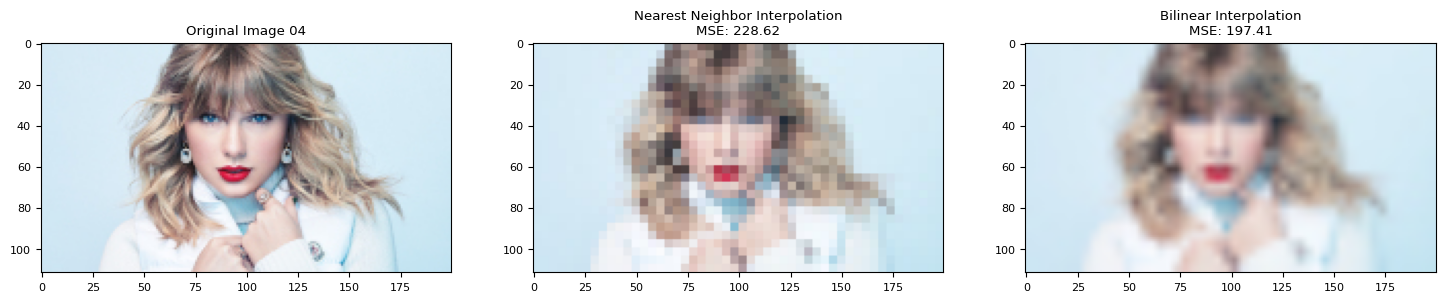

In [384]:
# Image 04
image04_nearest = zoom(img04small, 4, 'nearest')
image04_bilinear = zoom(img04small, 4, 'bilinear')
image04_mse_nearest = Mean_Squared_Error(image04_nearest, img04)
image04_mse_bilinear = Mean_Squared_Error(image04_bilinear, img04)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img04, cmap='gray')
axes[0].set_title('Original Image 04')

axes[1].imshow(image04_nearest, cmap='gray')
axes[1].set_title(f'Nearest Neighbor Interpolation\nMSE: {image04_mse_nearest:.2f}')

axes[2].imshow(image04_bilinear, cmap='gray')
axes[2].set_title(f'Bilinear Interpolation\nMSE: {image04_mse_bilinear:.2f}')

Question 09